# Solar Yield Production Model

This notebook reuses the solar feature pipeline and trains a smaller AutoGluon model intended for production inference.

In [3]:
import json
import logging
import shutil
import sys
import os

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

# Walk upwards until we find the repo root (where "common" lives)
p = Path.cwd()
while p != p.parent and not (p / "common").exists():
    p = p.parent
sys.path.insert(0, str(p))

# Find repo root (where env.local lives)
env_root = Path.cwd()
while env_root != env_root.parent and not (env_root / "env.local").exists():
    env_root = env_root.parent

load_dotenv(env_root / "env.local")
print("Loaded env.local:", env_root / "env.local")

from common.db_repository import DbRepository
from predicthelper import PredictHelper

Loaded env.local: /home/gerbrand/PycharmProjects/EnergySchedulerNuc/env.local


In [4]:
connection_string = os.environ.get("energydb")
repo = DbRepository(connection_string=connection_string, logger=logging.getLogger(__name__))
try:
    rows = repo.get_hourly_solar_with_weather()
finally:
    repo.close()

helper = PredictHelper("Europe/Amsterdam")
df = helper.build_feature_dataframe(rows)

# Clean up any missing data
df = df.dropna().sort_values("Timestamp").reset_index(drop=True)

# Normalize timestamps to UTC and drop tz for modeling
df["Timestamp"] = pd.to_datetime(df["Timestamp"], utc=True)
df["Timestamp"] = df["Timestamp"].dt.tz_convert("UTC").dt.tz_localize(None)
df.head()

,Timestamp,solar_total,pressure,temperature,cloud_are_fraction,precipitation,humidity,wind_from_direction,wind_speed,Sun_Angle,Sun_Angle_Trend,hour_sin,hour_cos,wd_sin,wd_cos
0,2025-05-11 20:00:00,0.0,1011.799988,17.5,0.0,0.0,54.000000,88.900002,3.7,0.0,-1,-0.500000,0.866025,-0.781831,0.62349
1,2025-05-11 21:00:00,0.0,1011.900024,16.9,0.0,0.0,56.299999,105.300003,3.5,0.0,-1,-0.258819,0.965926,-0.781831,0.62349
2,2025-05-11 22:00:00,0.0,1012.099976,15.9,0.0,0.0,62.799999,99.199997,3.4,0.0,-1,0.000000,1.000000,0.000000,1.00000
3,2025-05-11 23:00:00,0.0,1012.000000,15.5,0.0,0.0,65.699997,101.500000,3.6,0.0,-1,0.258819,0.965926,0.000000,1.00000
4,2025-05-12 00:00:00,0.0,1012.099976,14.7,0.0,0.0,69.000000,106.500000,3.8,0.0,-1,0.500000,0.866025,0.000000,1.00000


In [5]:
target_col = "solar_total"
feature_cols = [
    "pressure",
    "temperature",
    "cloud_are_fraction",
    "precipitation",
    "humidity",
    "wind_from_direction",
    "wind_speed",
    "Sun_Angle",
    "Sun_Angle_Trend",
    "hour_sin",
    "hour_cos",
    "wd_sin",
    "wd_cos",
]

model_df = df[["Timestamp", target_col, *feature_cols]].copy()
model_df.head()

,Timestamp,solar_total,pressure,temperature,cloud_are_fraction,precipitation,humidity,wind_from_direction,wind_speed,Sun_Angle,Sun_Angle_Trend,hour_sin,hour_cos,wd_sin,wd_cos
0,2025-05-11 20:00:00,0.0,1011.799988,17.5,0.0,0.0,54.000000,88.900002,3.7,0.0,-1,-0.500000,0.866025,-0.781831,0.62349
1,2025-05-11 21:00:00,0.0,1011.900024,16.9,0.0,0.0,56.299999,105.300003,3.5,0.0,-1,-0.258819,0.965926,-0.781831,0.62349
2,2025-05-11 22:00:00,0.0,1012.099976,15.9,0.0,0.0,62.799999,99.199997,3.4,0.0,-1,0.000000,1.000000,0.000000,1.00000
3,2025-05-11 23:00:00,0.0,1012.000000,15.5,0.0,0.0,65.699997,101.500000,3.6,0.0,-1,0.258819,0.965926,0.000000,1.00000
4,2025-05-12 00:00:00,0.0,1012.099976,14.7,0.0,0.0,69.000000,106.500000,3.8,0.0,-1,0.500000,0.866025,0.000000,1.00000


## Shuffled Split

Because we are explicitly avoiding historical lags, each row is treated as an independent supervised sample. That makes a shuffled holdout valid for this experiment.

In [6]:
from sklearn.model_selection import train_test_split

SEED = 42
TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
)

# Keep each split ordered by time for inspection and plotting.
train_df = train_df.sort_values("Timestamp").reset_index(drop=True)
test_df = test_df.sort_values("Timestamp").reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 3492
Test rows: 874


## Train Compact Production Model

This trains a single AutoGluon Torch tabular network without bagging or stacking to keep the production artifact smaller.

In [7]:
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

train_data = train_df[[target_col, *feature_cols]].copy()
test_data = test_df[[target_col, *feature_cols]].copy()
test_features = test_df[feature_cols].copy()
y_test = test_df[target_col].to_numpy()

prod_path = Path("AutogluonModels") / "solar_yield_prod_nn"

predictor_prod = TabularPredictor(
    label=target_col,
    problem_type="regression",
    path=str(prod_path),
    eval_metric="mean_absolute_error",
)

predictor_prod.fit(
    train_data=train_data,
    hyperparameters={
        "NN_TORCH": {},
    },
    num_bag_folds=0,
    num_stack_levels=0,
    verbosity=2,
)

y_pred = predictor_prod.predict(test_features)
y_pred = pd.Series(y_pred).clip(lower=0).to_numpy()

results_prod = pd.DataFrame([
    {
        "model": "NN_TORCH_production",
        "mae": mean_absolute_error(y_test, y_pred),
        "rmse": mean_squared_error(y_test, y_pred) ** 0.5,
        "r2": r2_score(y_test, y_pred),
    }
])
results_prod

/home/gerbrand/PycharmProjects/EnergySchedulerNuc/.venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Feb 19 19:54:01 UTC 2026
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.25 GB / 15.32 GB (21.2%)
Disk Space Avail:   191.79 GB / 411.34 GB (46.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.

,model,mae,rmse,r2
0,NN_TORCH_production,0.011805,0.02571,0.845769


,Timestamp,solar_total,prediction
0,2025-05-12 04:00:00,0.00,1.447830e-18
1,2025-05-12 10:00:00,0.07,6.359709e-02
2,2025-05-12 13:00:00,0.33,3.178414e-01
3,2025-05-12 19:00:00,0.00,1.168875e-04
4,2025-05-12 22:00:00,0.00,4.772058e-23
5,2025-05-13 01:00:00,0.00,5.151829e-20
6,2025-05-13 02:00:00,0.00,4.920490e-19
7,2025-05-13 04:00:00,0.00,6.377137e-20
8,2025-05-13 05:00:00,0.00,2.974610e-03
9,2025-05-13 15:00:00,0.27,2.682703e-01


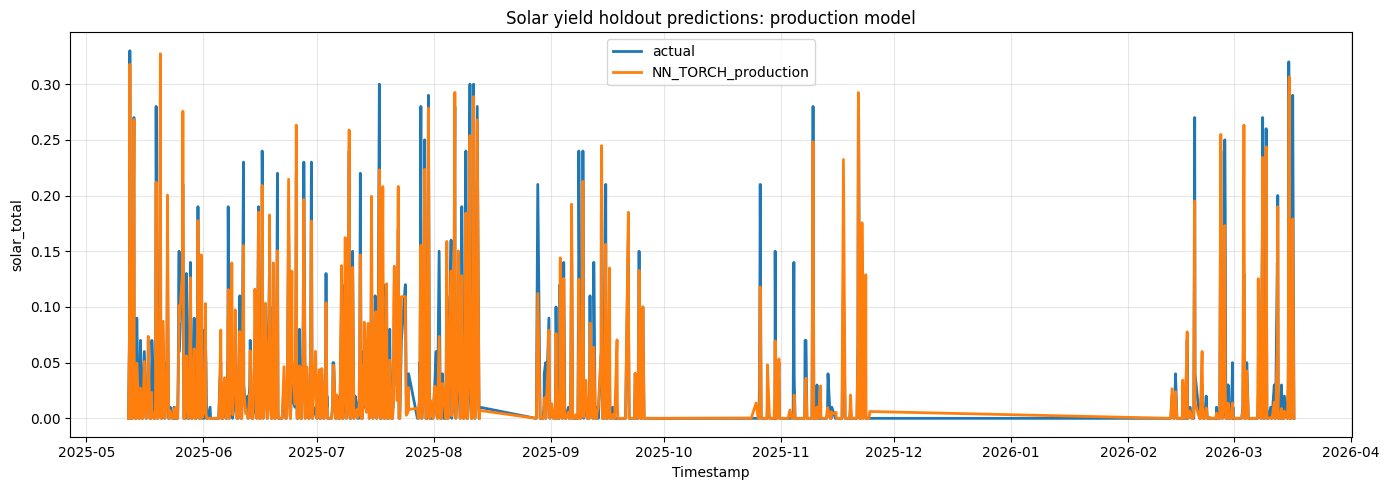

In [8]:
plot_df = test_df[["Timestamp", target_col]].copy()
plot_df["prediction"] = y_pred
plot_df = plot_df.sort_values("Timestamp").reset_index(drop=True)

display(plot_df.head(20))

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Timestamp"], plot_df[target_col], label="actual", linewidth=2)
plt.plot(plot_df["Timestamp"], plot_df["prediction"], label="NN_TORCH_production", linewidth=2)
plt.title("Solar yield holdout predictions: production model")
plt.xlabel("Timestamp")
plt.ylabel("solar_total")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save For Production

This copies the compact predictor to the repo `Models/solar_yield_model` directory used by the scheduler.

In [9]:
project_root = env_root
source_dir = Path("AutogluonModels") / "solar_yield_prod_nn"
target_dir = project_root / "Models" / "solar_yield_model"

if not source_dir.exists():
    raise FileNotFoundError(f"Production model folder not found: {source_dir}")

target_dir.parent.mkdir(parents=True, exist_ok=True)

if target_dir.exists():
    shutil.rmtree(target_dir)

shutil.copytree(source_dir, target_dir)

metadata = {
    "model": "NN_TORCH_production",
    "results": results_prod.iloc[0].to_dict(),
    "source_dir": str(source_dir.resolve()),
    "target_dir": str(target_dir.resolve()),
}

(target_dir / "selection.json").write_text(json.dumps(metadata, indent=2))

print(f"Saved production model to: {target_dir}")
display(results_prod)

Saved production model to: /home/gerbrand/PycharmProjects/EnergySchedulerNuc/Models/solar_yield_model


,model,mae,rmse,r2
0,NN_TORCH_production,0.011805,0.02571,0.845769
